In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Union
import logging
import matplotlib as mpl
from utils.feature_generation import  _calc_features_mp, _create_features_df, _get_indicators_list
from utils.fractional_diff import calc_min_d, fast_frac_diff
from utils.labeling import get_barrier_events, get_bins

from tqdm.contrib import tenumerate

mpl.rcParams['ytick.labelsize'] = 14
mpl.rcParams['xtick.labelsize'] = 14

pd.options.display.max_rows = 4000
pd.options.display.max_seq_items = 2000
np.random.seed(42)

logging.getLogger("pandas").setLevel(logging.ERROR)

In [2]:
ticker = 'AAPL'
n_cpus = 8
data_path = Path('bars/aapl_dollar_bars.h5')
bars = pd.read_hdf(data_path.resolve(), key='key')
bars.drop(['tick_num', 'cum_buy_volume', 'cum_ticks', 'cum_dollar_value'], axis=1, inplace=True)
bars.set_index('date_time', inplace=True)
bars = bars[~bars.index.duplicated()]

display(bars.head())

,open,high,low,close,volume
date_time,,,,,
2019-11-07 16:28:57.758,259.7026,259.7700,259.48,259.66,320759.0
2019-11-07 16:37:26.188,259.6600,259.8500,259.61,259.73,320271.0
2019-11-07 16:46:59.795,259.7300,259.7453,259.50,259.50,321204.0
2019-11-07 16:54:07.176,259.5000,259.6000,259.13,259.18,320711.0
2019-11-07 16:59:24.869,259.1800,259.9500,259.07,259.55,320834.0


In [3]:
def calc_fractional_diff(df: pd.DataFrame, thresh: np.float64=1e-3) -> pd.DataFrame:
    cols = ['open', 'high', 'low', 'close']
    diffed_df = df.copy(deep=True)[cols]
    
    if diffed_df.index.name == 'date_time':
        diffed_df.reset_index(inplace=True)

    min_d = calc_min_d(diffed_df['close'], col_name='close', thresh=thresh)
    if min_d is None:
        min_d = calc_min_d(diffed_df['close'].cumsum(), col_name='close', thresh=thresh)
        if min_d is None:
            return 0, df
        
    for _, col in tenumerate(cols, desc='Differentiating'):
        diffed_series = fast_frac_diff(diffed_df[col], diff_amt=min_d, col_name=col, thresh=thresh).dropna()
        diffed_df.drop(col, axis=1, inplace=True)
        diffed_df.loc[:, col] = diffed_series

    if 'volume' in df.columns:
        diffed_df = pd.concat([diffed_df, df.loc[:, 'volume'].reset_index(drop=True)], axis=1)

    if 'date_time' in diffed_df.columns:
        diffed_df.set_index('date_time', drop=True, inplace=True)
    return min_d, diffed_df


Differentiating:   0%|          | 0/4 [00:00<?, ?it/s]

,open,high,low,close,volume
date_time,,,,,
2019-11-14 17:41:01.454,18.474270,19.997171,18.619737,18.866845,316401.0
2019-11-14 17:50:57.544,18.876419,18.227188,18.962564,18.778135,316137.0
2019-11-14 18:00:54.598,18.761396,18.443021,18.713654,18.666830,316110.0
2019-11-14 18:08:35.748,18.613028,19.682551,18.601773,18.814423,316398.0
2019-11-14 18:20:13.461,18.828663,18.418351,18.803475,18.489926,316521.0


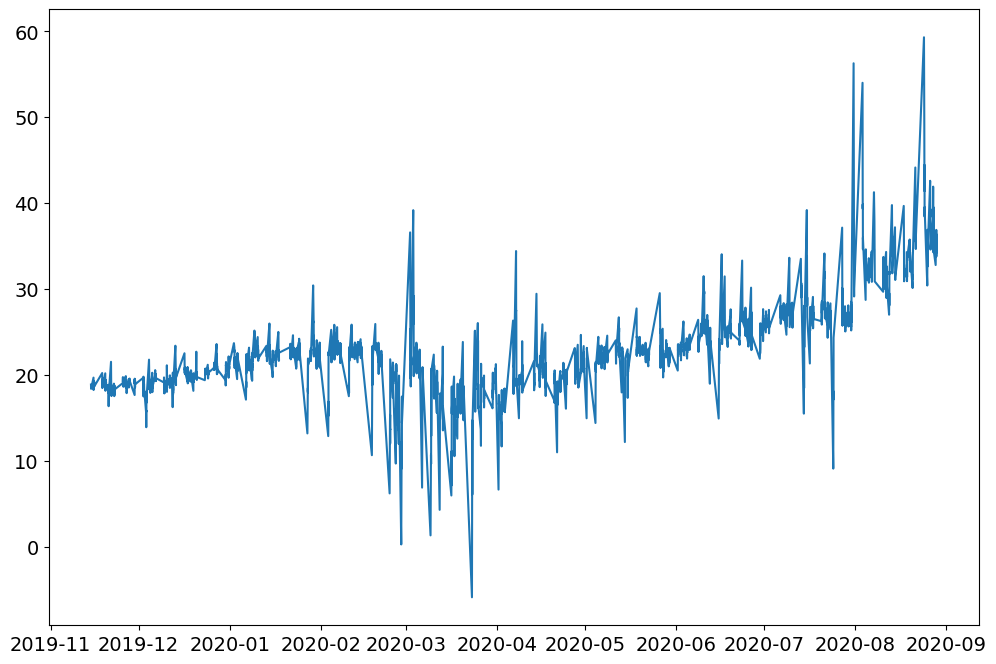

In [4]:
min_d, diffed_bars = calc_fractional_diff(bars, thresh=1e-4)
diffed_bars = diffed_bars.dropna()

display(diffed_bars.head())

plt.figure(figsize=(12, 8))
plt.plot(diffed_bars.index, diffed_bars['close'])
plt.show()

In [5]:
def create_ta_features(
    bars: pd.DataFrame,
    n_jobs: int = 2,
    verbose: bool = True,
    indicators: Union[List, None] = None
) -> pd.DataFrame:
    """
    Generate technical analysis (TA) features for a given input DataFrame of market bars.

    This function applies a set of technical indicators to the input `bars` DataFrame, possibly in parallel,
    and returns a DataFrame consisting of the computed indicator features for each row in the original data.
    The function removes certain columns that are not required ('tick_num', 'cum_ticks', 'cum_dollar_value', 
    'cum_buy_volume'), and processes the data indexed by 'date_time' if available.

    Parameters
    ----------
    bars : DataFrame
        Input DataFrame containing at least the columns 'open', 'high', 'low', 'close', 'volume', 'date_time' and indexed by 'date_time'.
    n_jobs : int, optional
        Number of parallel jobs/processes to use, by default 1.
    verbose : bool, optional
        Whether to print detailed informational messages, by default True.
    lags : List, optional
        List of lag periods for indicator computation, by default [1, 10]. (Currently not directly used inside the function.)
    indicators : List, optional
        List of indicator specifications. If None, default indicators are fetched.

    Returns
    -------
    DataFrame
        DataFrame containing the generated technical analysis features, indexed by 'date_time' if present,
        and with input price/volume columns dropped.

    Notes
    -----
    This function uses multiprocessing to parallelize feature calculation across indicators.
    uvRequires certain columns to be present in the input DataFrame and will drop unused columns.
    """
    ta_bars = bars.copy(deep=True)

    if 'date_time' in bars.columns:
        ta_bars.set_index(['date_time'], inplace=True)
    ta_bars = ta_bars.dropna()

    indicators = _get_indicators_list() if indicators is None else indicators

    outs = _calc_features_mp(bars=ta_bars, indicator_list=indicators, n_jobs=n_jobs, verbose=verbose)
    features_df = _create_features_df(outs).reset_index()

    print('features dataframe successfully created')
    return features_df.drop(columns=['open', 'high', 'low', 'close', 'volume'])



In [6]:
ta_features = create_ta_features(diffed_bars)

ta_features = ta_features.iloc[:, np.where(ta_features.isna().sum() < 44)[0]]
display(ta_features.tail())

Numbers of indicators added to multiprocessing jobs: 123


/Users/Vahid/github/financial_ml/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/Vahid/github/financial_ml/.venv/lib/python3.12/site-packages/pandas_ta/performance/log_return.py:50: RuntimeWarning: invalid value encountered in log
  log_return = Series(log(r), index=close.index)


features dataframe successfully created


2026-03-08 20:04:55.805636 100.0%  done after 0.01 minutes. Remaining 0.0 minutes.


,date_time,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,AD,ACCBL_20,ACCBM_20,ACCBU_20,ADOSC_3_10,...,VTXP_14,VTXM_14,VWAP_D,VWMA_10,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30,VIDYA_14
10287,2020-08-28 14:10:15.052,35.306543,35.837481,34.775606,0.530937,2.493922e+09,35.129390,35.103279,34.974802,-8.513452e+05,...,0.963251,0.879779,34.991423,35.566450,139.785116,-55.850654,35.401814,35.159106,0.455676,35.577817
10288,2020-08-28 14:12:50.870,35.286560,35.857125,34.715994,0.570565,2.493619e+09,35.072266,35.153524,35.210020,-1.173642e+06,...,1.023225,0.858346,35.004788,35.514134,141.837448,-76.796468,35.301782,35.094315,0.070568,35.568893
10289,2020-08-28 14:15:07.435,35.179249,35.761422,34.597076,0.582173,2.493222e+09,35.189482,35.220489,35.143309,-1.324978e+06,...,1.156667,1.035643,34.998692,35.401885,139.267616,-71.334230,35.228985,34.984855,0.210137,35.563862
10290,2020-08-28 14:16:59.436,34.998876,35.568833,34.428918,0.569957,2.493104e+09,35.188049,35.266352,35.229902,-1.304112e+06,...,1.082119,1.044496,34.994957,35.250988,139.316923,-85.597008,35.130319,35.003542,-0.187255,35.554397
10291,2020-08-28 14:19:07.123,35.043016,35.605908,34.480125,0.562892,2.493053e+09,35.258700,35.328045,35.260468,-1.193119e+06,...,0.980887,1.037784,34.999745,35.212940,140.940518,-63.652048,35.130316,35.046576,0.352532,35.552760


In [7]:
print(f'Features dataframe shape: {ta_features.shape}')
# print(f'\nFeature names: \n{ta_features.columns}')

# Randomly choose 50 features
# Just to speed up the selection process for demonstration
features = randomly_chosen = np.random.choice(ta_features.columns, size=50)
feat_df = ta_features.loc[:, features]
print(f'Example dataframe shape: {feat_df.shape}')

Features dataframe shape: (10292, 169)
Example dataframe shape: (10292, 51)



## Labeling

In [ ]:
pt_sl = [1., 1.]
avg_events_per_day = 10
num_days_avg_vol = 90
min_ret = 0.001
triple_barrier_events = get_barrier_events(
                                         bars=bars,
                                         n_jobs=n_cpus,
                                         avg_events_per_day=avg_events_per_day,
                                         num_days_avg_vol=num_days_avg_vol,
                                         min_ret= min_ret,
                                         pt_sl=pt_sl,
                                         side_prediction=None)

labels = get_bins(triple_barrier_events, bars['close'])
print("Label value counts:")
print(labels.bin.value_counts())
print('labels count: ', labels.shape[0])

Volatility averaged for the last 90 days
1/10 of average daily volatility used as filter_threshold for the cumsum filter
(294,)
2020-04-22 16:46:16.343   NaN
2020-04-23 12:00:02.252   NaN
2020-04-23 13:33:17.980   NaN
2020-04-23 13:34:34.216   NaN
2020-04-23 13:36:15.383   NaN
Name: vertical, dtype: float64
<class 'numpy.float64'>
(294,)
2019-11-14 17:21:46.777   NaN
2019-11-14 17:41:01.454   NaN
2019-11-20 15:30:24.288   NaN
2019-11-20 15:35:39.169   NaN
2019-11-20 15:56:41.797   NaN
Name: vertical, dtype: float64
<class 'numpy.float64'>
(293,)
2020-02-10 14:38:24.239   NaN
2020-02-10 14:40:56.988   NaN
2020-02-10 14:42:07.133   NaN
2020-02-10 14:56:55.246   NaN
2020-02-10 14:57:50.976   NaN
Name: vertical, dtype: float64
<class 'numpy.float64'>
(294,)
2020-01-03 14:47:23.531   NaN
2020-01-03 15:06:10.235   NaN
2020-01-03 15:08:35.409   NaN
2020-01-03 15:10:54.645   NaN
2020-01-03 15:16:15.298   NaN
Name: vertical, dtype: float64
<class 'numpy.float64'>
(294,)
2020-06-24 14:02:40.049 

/Users/Vahid/github/financial_ml/utils/labeling.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(type(events_['vertical'][0]))
/Users/Vahid/github/financial_ml/utils/labeling.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(type(events_['vertical'][0]))
/Users/Vahid/github/financial_ml/utils/labeling.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(type(events_['vertical'][0]))
/Users/Vahid/github/finan

TypeError: float() argument must be a string or a real number, not 'Timestamp'

In [ ]:
labels

,return,target,bin
2019-11-14 17:21:46.777,0.005366,0.005123,1
2019-11-14 17:41:01.454,0.005965,0.005091,1
2019-11-20 15:30:24.288,-0.005814,0.005314,-1
2019-11-20 15:35:39.169,-0.005542,0.005256,-1
2019-11-20 15:56:41.797,-0.006503,0.005173,-1
2019-11-20 17:18:18.349,-0.005232,0.005086,-1
2019-11-20 17:47:46.877,-0.006057,0.005047,-1
2019-11-20 18:00:35.979,0.008257,0.006199,1
2019-11-20 18:03:14.731,0.006564,0.006286,1
2019-11-20 18:15:05.704,0.010536,0.006866,1


In [ ]:
# bars = bars.loc[labels.index, :]
bars = bars.iloc[indexes, :]
bars

NameError: name 'indexes' is not defined

## Fractional Differentiation

In [ ]:
def df_aggregate(df, bars):
    new_df = pd.DataFrame(index=bars.index, columns=['open', 'high', 'low', 'close', 'volume'])
    prev_index = None
    i = 0
    for row in bars.itertuples():
        if prev_index is None:
            prev_index = row.Index
            new_df['open'].iloc[i] = np.nan
            new_df['high'].iloc[i] = np.nan
            new_df['low'].iloc[i] = np.nan
            new_df['close'].iloc[i] = np.nan
            new_df['volume'].iloc[i] = np.nan
            i += 1
            continue
        start_index = prev_index
        if i == 1:
            start_iloc = df.index.get_loc(start_index, method='pad')
        else:
            start_iloc = df.index.get_loc(start_index, method='pad') + 1
        end_iloc = df.index.get_loc(row.Index, method='pad')

        if start_iloc == end_iloc:
            new_df.loc[row.Index, 'open'] = df['open'].iloc[start_iloc]
            new_df.loc[row.Index, 'high'] = df['high'].iloc[start_iloc]
            new_df.loc[row.Index, 'low'] = df['low'].iloc[start_iloc]
            new_df.loc[row.Index, 'close'] = df['close'].iloc[end_iloc]
            new_df.loc[row.Index, 'volume'] = df['volume'].iloc[start_iloc]
        else:
            new_df.loc[row.Index, 'open'] = df['open'].iloc[start_iloc]
            new_df.loc[row.Index, 'high'] = df['high'].iloc[start_iloc:end_iloc].max()
            new_df.loc[row.Index, 'low'] = df['low'].iloc[start_iloc:end_iloc].min()
            new_df.loc[row.Index, 'close'] = df['close'].iloc[end_iloc]
            new_df.loc[row.Index, 'volume'] = df['volume'].iloc[start_iloc:end_iloc].sum()
        prev_index = row.Index
        i += 1
    return new_df

In [ ]:
bars_ej = df_aggregate(bars_ej, bars)
bars_eu = df_aggregate(bars_eu, bars)

for col in bars_ej.columns:
    bars_ej[col] = bars_ej[col].astype(np.float64)
    bars_eu[col] = bars_eu[col].astype(np.float64)

In [ ]:
print(bars_ej.head())
print(bars_ej.tail())

In [ ]:
bars = bars.reset_index().drop(0, axis=0).reset_index(drop=True)
bars_eu = bars_eu.reset_index().drop(0, axis=0).reset_index(drop=True)
bars_ej = bars_ej.reset_index().drop(0, axis=0).reset_index(drop=True)

In [ ]:
ej_bars_path = Path().resolve().parent/'data'/'bars'/'EURJPY_minute_bars_aggregated_3.h5'
bars_ej = pd.read_hdf(ej_bars_path, 's')

eu_bars_path = Path().resolve().parent/'data'/'bars'/'EURUSD_minute_bars_aggregated_3.h5'
bars_eu = pd.read_hdf(eu_bars_path, 's')

In [ ]:
# ej_bars_path = Path().resolve().parent/'data'/'bars'/'EURJPY_minute_bars_aggregated_2.h5'
# bars_ej.to_hdf(ej_bars_path, mode='w', key='s', data_columns=True)

# eu_bars_path = Path().resolve().parent/'data'/'bars'/'EURUSD_minute_bars_aggregated_2.h5'
# bars_eu.to_hdf(eu_bars_path, mode='w', key='s', data_columns=True)

In [ ]:
%%time
%autoreload 2

min_d, new_bars = mylib.ml_utils.calc_fractional_diff(bars, thresh=1e-4)
min_d_ej, new_bars_ej = mylib.ml_utils.calc_fractional_diff(bars_ej, thresh=1e-3)
min_d_eu, new_bars_eu = mylib.ml_utils.calc_fractional_diff(bars_eu, thresh=1e-3)
min_d

In [ ]:
bars_eu = new_bars_eu.dropna()
bars = new_bars.loc[bars_eu.index]
bars_ej = new_bars_ej.loc[bars_eu.index]

bars = bars.reset_index(drop=True)
bars_ej = bars_ej.reset_index(drop=True)
bars_eu = bars_eu.reset_index(drop=True)

In [ ]:
min_d

## TS features

In [ ]:
# %%time
# %autoreload 2

# from tsfresh.feature_extraction import (MinimalFCParameters,
#                                         EfficientFCParameters,
#                                         ComprehensiveFCParameters)
# ts_features = mylib.feature_generation.create_ts_features(bars=bars,
#                                                           periods=periods,
#                                                           n_jobs=n_cpus,
#                                                           parameters=ComprehensiveFCParameters)
# ts_features.tail()

## TA features

In [ ]:
# bars = bars.set_index('date_time')
# bars_ej = bars_ej.set_index('date_time')
# bars_eu = bars_eu.set_index('date_time')

In [ ]:
%autoreload 2
lags = [5, 10, 20, 60]

# bars = bars.set_index('date_time')
ta_features = mylib.feature_generation.create_ta_features(bars, n_jobs=20, verbose=True, lags=lags)
ta_features_ej = mylib.feature_generation.create_ta_features(bars_ej, n_jobs=20, verbose=True, lags=lags)
ta_features_eu = mylib.feature_generation.create_ta_features(bars_eu, n_jobs=20, verbose=True, lags=lags)
# ta_features.tail(10)

In [ ]:
%autoreload 2
importlib.reload(mylib)
my_ta = mylib.feature_generation.add_my_features(bars)
# my_ta_ej = add_my_features(bars_ej)
# my_ta_eu = add_my_febatures(bars_eu)
my_ta.index = bars['date_time']


In [ ]:
my_ta.isna().sum().sort_values(ascending=False)

In [ ]:
my_ta.tail(120)

In [ ]:
bars = bars.dropna()

In [ ]:
# ta_features = ta_features.drop(ta_features.columns[ta_features.isna().sum() > 200], axis=1).fillna(method='ffill')
# ta_features_ej = ta_features_ej.drop(ta_features_ej.columns[ta_features_ej.isna().sum() > 200], axis=1).fillna(method='ffill')
# ta_features_eu = ta_features_eu.drop(ta_features_eu.columns[ta_features_eu.isna().sum() > 200], axis=1).fillna(method='ffill')
my_ta = my_ta.drop(my_ta.columns[my_ta.isna().sum() > 1200], axis=1).fillna(method='ffill')


In [ ]:
ta_features = ta_features.loc[:, ~ta_features.columns.duplicated()]
ta_features_ej = ta_features_ej.loc[:, ~ta_features_ej.columns.duplicated()]
ta_features_eu = ta_features_eu.loc[:, ~ta_features_eu.columns.duplicated()]

In [ ]:
import pandas_ta as ta
tas = []
periods = [5, 14, 25, 60]
bars.set_index('date_time', inplace=True)
for period in periods:
    tas.append(ta.trend.adx(high=np.log(bars.high), low=np.log(bars.low), close=np.log(bars.close), mamode='ema', length=period))
    tas.append(ta.trend.aroon(high=np.log(bars.high), low=np.log(bars.low), length=period))
    tas.append(ta.trend.dpo(close=np.log(bars.close), length=period))

    tas.append(ta.momentum.kst(close=np.log(bars.close), signal=period))
    tas.append(ta.momentum.macd(close=np.log(bars.close), fast=14, slow=52, length=period))
    tas.append(ta.momentum.macd(close=np.log(bars.close), fast=14, slow=120, length=period))
    tas.append(ta.momentum.macd(close=np.log(bars.close), fast=14, slow=252, length=period)) 
    tas.append(ta.momentum.macd(close=np.log(bars.close), fast=25, slow=52, length=period))
    tas.append(ta.momentum.macd(close=np.log(bars.close), fast=25, slow=120, length=period))
    tas.append(ta.momentum.macd(close=np.log(bars.close), fast=25, slow=252, length=period))   

    for p2 in periods:
        if p2 > period:
            tas.append(ta.momentum.trix(close=np.log(bars.close), length=period, signal=p2))
        else:
            continue
    tas.append(ta.overlap.vwap(high=np.log(bars.high), low=np.log(bars.low), close=np.log(bars.close), volume=bars.volume, offset=period))

tas = pd.concat(tas, axis=1)
tas.reset_index(inplace=True)
# bars.reset_index(inplace=True)
ta_features = pd.concat([ta_features, tas], axis=1)
ta_features = ta_features.loc[:, ~ta_features.columns.duplicated()]
ta_features.reset_index(drop=True, inplace=True)
ta_features.tail(10)

In [ ]:
ta_features['date_time'] = bars.index
# ta_features = ta_features.fillna(method='ffill').dropna()

In [ ]:
# ta_file_path = Path().resolve().parent/'data'/'features_data'/'USDJPY_dollar_50bpd_ta_df.h5'
# ta_features.to_hdf(ta_file_path, mode='w', key='s', data_columns=True)

# ta_ej_file_path = Path().resolve().parent/'data'/'features_data'/'EURJPY_dollar_50bpd_ta_df.h5'
# ta_features_ej.to_hdf(ta_ej_file_path, mode='w', key='s', data_columns=True)

# ta_eu_file_path = Path().resolve().parent/'data'/'features_data'/'EURUSD_dollar_50bpd_ta_df.h5'
# ta_features_eu.to_hdf(ta_eu_file_path, mode='w', key='s', data_columns=True)

my_ta_file_path = Path().resolve().parent/'data'/'features_data'/'USDJPY_dollar_50bpd_my_ta.h5'
my_ta.to_hdf(my_ta_file_path, mode='w', key='s', data_columns=True)
# ts_features.reset_index(drop=True, inplace=True)
# ta_features.reset_index(drop=True, inplace=True)
# bars.reset_index(inplace=True)

In [ ]:
my_ta.isna().sum()

In [ ]:
ss = pd.DataFrame(get_v(bars.reset_index())['tick'].head(1000))

## My Features

In [ ]:
s1 = pd.DataFrame(get_a(bars))
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
s1 = sc.fit_transform(s1)
s1 = pd.DataFrame(s1, columns=['tick', 'time', 'volume'])
s1

In [ ]:
my_ta = add_my_features(bars.reset_index())
my_ta

In [ ]:
my_ta['v_time'].head(200)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
v = pd.Series(get_v(bars, bases=['tick'])['tick']).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=np.float64).reshape(-1,1)
print(v.min())
print(v.max())
ssmean = v.flatten().mean()
ssstd = v.flatten().std()
print(ssmean,'\n', ssstd)
nnew = sc.fit_transform(v)
print(nnew.ravel().mean())
print(nnew.ravel().std())


# nnew

In [ ]:
v

In [ ]:
# bars.reset_index(inplace=True)
my_bars_ta = add_my_features(bars)
# my_bars_ej_ta = add_my_features(bars_ej)
# my_bars_eu_ta = add_my_features(bars_eu)

# my_tas = pd.concat([my_bars_ta, my_bars_ej_ta, my_bars_eu_ta], axis=1)
my_bars_ta


In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit_transform(my_bars_ta)
my_bars_ta*1e6

## Calculating Entropy Features and add tick_rule

In [ ]:
bars.rename(columns={'tick_num':'end_index'}, inplace=True)
bars['start_index'] = bars['end_index'].shift(1)
bars.loc[0,'start_index'] = 0
bars['start_index'] = bars['start_index'].astype(int)
# bars.reset_index(inplace=True)
# bars = bars[['date_time', 'open', 'high', 'low', 'close', 'volume', 'cum_dollar_value' 'start_index', 'end_index']]
bars.head()

In [ ]:
%%time
%autoreload 2
entropy_feat = mylib.feature_generation.get_entropy_features(tick_df, bars, verbose=True, n_jobs=n_cpus)
entropy_feat.tail()

In [ ]:
%%time
%autoreload 2
trade_micro_feat = mylib.feature_generation.get_trade_micro_features(tick_df,
                                                                     bars,
                                                                     verbose=True,
                                                                     n_jobs=n_cpus)
trade_micro_feat.tail()

In [ ]:
other_micro_features = mylib.feature_generation.get_other_features(bars, periods)
other_micro_features.tail()

In [ ]:
%%time

if 'start_index' in bars.columns:
    bars.drop('start_index', axis=1, inplace=True)
if 'end_index' in bars.columns:
    bars.drop('end_index', axis=1, inplace=True)
if 'cum_ticks' in bars.columns:
    bars.drop('cum_ticks', axis=1, inplace=True)
if 'cum_dollar_value' in bars.columns:
    bars.drop('cum_dollar_value', axis=1, inplace=True)
if 'cum_buy_volume' in bars.columns:
    bars.drop('cum_buy_volume', axis=1, inplace=True)

In [ ]:
df_list = [bars, entropy_feat, trade_micro_feat, other_micro_features, ta_features, ts_features]
f_df = pd.concat(df_list, axis=1)
# f_df = f_df.loc[:,~f_df.columns.duplicated()]

In [ ]:
del bars, ta_features, ts_features, entropy_feat, trade_micro_feat, other_micro_features, tick_df

## Dropping duplicate columns, and columns with lots of zeros and nulls

In [ ]:
# %autoreload 2
# prev_shape = f_df.shape

# f_df = mylib.feature_selection.drop_null_columns(f_df)
# f_df = mylib.feature_selection.drop_zeros(f_df)

# duplicated_feat, duplicated_feat_pairs = mylib.feature_selection.find_duplicate_feat(f_df)
# f_df = f_df[duplicated_feat_pairs.keys()]
# f_df = mylib.feature_selection.drop_duplicate_columns(f_df)

# print('Number of droped duplicate features: '+str(len(duplicated_feat)))
# print(f'features_df previous shape is {prev_shape} and curent shape is {f_df.shape}')

In [ ]:
# nulls = mylib.feature_selection.find_null_columns(f_df)
# zeros = mylib.feature_selection.find_zeros(f_df)

# nulls, zeros

In [ ]:
%%time
%autoreload 2

duplicate_names = f_df.columns[f_df.columns.duplicated()].to_list()
# duplicate_values = mylib.feature_selection.find_duplicate_columns(f_df)
# nulls = mylib.feature_selection.find_null_columns_np(f_df)
# zeros = mylib.feature_selection.find_zeros_np(f_df)

drops = duplicate_names + duplicate_values
drops = list(set(drops))
# print(f'Useless columns: {drops}')
print('Number of usless columns: '+str(len(drops)))
# print(f'features_df previous shape is {prev_shape} and curent shape is {f_df.shape}')

In [ ]:
f_df.drop(drops, axis=1, inplace=True)

In [ ]:
f_df = f_df.loc[:, ~f_df.columns.duplicated()]

In [ ]:
# col_list = list(f_df.columns)
# import pickle
# pk_path = Path().resolve().parent/'data'/'features_data'/'feature_names.pkl'
# with open(pk_path, 'wb') as file:
#     pickle.dump(col_list, file)

In [ ]:
# f_df_file_path = Path().resolve().parent/'data'/'features_data'/'USDJPY_db_459K_f_df.h5'
# f_df.to_hdf(f_df_file_path, mode='w', key='s', data_columns=True)

labels_path = Path().resolve().parent/'data'/'features_data'/'USDJPY_50bpd_labels.h5'
labels.to_hdf(labels_path, mode='w', key='s', data_columns=True)

events_path = Path().resolve().parent/'data'/'features_data'/'USDJPY_50bpd_events.h5'
triple_barrier_events.to_hdf(events_path, mode='w', key='s', data_columns=True)

## *** End***

# Mutual Information Analysis

In [ ]:
# # to obtain the mutual information values
# from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

# # to select the features
# from sklearn.feature_selection import SelectKBest, SelectPercentile

# # calculate the mutual information between the variables and the target
# # the smaller the value of the mi, the less information we can infer from
# # the feature about the target

# mi = mutual_info_classif(X_train, y_train)
# # 1) let's capture the above array in a pandas series
# # 2) add the variable names in the index
# # 3) sort the features based on their mutual information value
# # 4) and make a var plot

# mi = pd.Series(mi)
# mi.index = X_train.columns
# mi = mi.sort_values(ascending=False)
# mi.head()
# ax = plt.gca()
# ax.tick_params(color='w', which='both')

# ax.set_xlabel('Features', color='w')
# ax.set_ylabel('Mutual Information', color='w')
# ax.tick_params(which='both', color='w', labelcolor='w')
# mi.sort_values(ascending=False).plot.bar(figsize=(20, 6))
# plt.show()


# Chi2 Analysis

In [ ]:
# # the scaler - for min-max scaling
# from sklearn.preprocessing import MinMaxScaler
# # set up the scaler
# scaler = MinMaxScaler()

# # fit the scaler to the train set, it will learn the parameters
# scaler.fit(X_train)

# # transform train and test sets
# X_train_scaled = scaler.transform(X_train)
# X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# # to determine the chi2 value
# from sklearn.feature_selection import chi2
# # calculate the chi2 p_value between each of the variables
# # and the target

# # chi2 returns 2 arrays, one contains the F-Scores which are then
# # evaluated against the chi2 distribution to obtain the pvalue.
# # The pvalues are in the second array
# f_score = chi2(X_train_scaled, y_train)

# pvalues = pd.Series(f_score[1])
# pvalues.index = X_train.columns
# pvalues = pvalues.sort_values(ascending=True)
# pvalues.head()
# # pvalues.sort_values(ascending=True).plot.bar(figsize=(20, 6))
# # plt.ylabel('CHI2')

In [ ]:
import pandas_ta as ta
bars.ta.indicator_list()

# PCA

In [ ]:
# from sklearn.decomposition import PCA
# # X_train, X_test, y_train, y_test = train_test_split_scale(X, y, 0.2, True)
# pca = PCA(n_components=10)
# # prepare transform on dataset
# pca.fit(X_train)

# # apply transform to dataset
# X_train_reduced = pca.transform(X_train)
# X_train_reduced[0]

In [ ]:
# Xdot = pd.DataFrame(get_orthogonal_features(X.iloc[:,:20]), index=X.index).add_prefix("PCA_")
# Xdot.head()

# KMeans Clustering

In [ ]:
# from sklearn.cluster import KMeans
# kmeans = KMeans(n_clusters=3)
# identified_clusters = kmeans.fit_predict(X_train_scaled.T)
# # print(identified_clusters.shape)
# data_with_clusters = X_train_scaled.copy().T
# data_with_clusters['Kmeans_Cluster'] = identified_clusters
# # print(data_with_clusters.shape)
# plt.figure(figsize=(14,8))
# # sns.scatterplot(x=data_with_clusters[0],y=data_with_clusters[938],hue=data_with_clusters['Kmeans_Cluster'],
# #                 c=data_with_clusters['Kmeans_Cluster'], palette=['g', 'r','c','m', 'b', 'y', 'k'])
# sns.scatterplot(x=data_with_clusters[0],y=data_with_clusters[938],hue=data_with_clusters['Kmeans_Cluster'],
#                 c=data_with_clusters['Kmeans_Cluster'], palette="deep")
# # plt.legend()
# # plt.xlim(-1,1)
# # plt.ylim(-90,90)
# plt.show()

In [ ]:
# data_with_clusters['Kmeans_Cluster'].value_counts()
# first_feat = data_with_clusters[data_with_clusters['Kmeans_Cluster']==0].index
# list(first_feat)

## Selecting the number of clusters for KMeans (The Elbow Method)

In [ ]:
# wcss=[]

# for i in range(1,24):
#     kmeans = KMeans(i)
#     kmeans.fit(X_train_scaled.T)
#     wcss_iter = kmeans.inertia_
#     wcss.append(wcss_iter)
    
# number_clusters = range(1,24)
# plt.figure(figsize=(12,8))

# plt.plot(number_clusters,wcss)
# plt.title('The Elbow Method')
# plt.xlabel('Number of clusters')
# plt.ylabel('Within-cluster Sum of Squares')
# plt.xlim(0,10)
# plt.show()

# Plot Random Forest Feature Importance (Soledad Ghali)

In [ ]:
# from sklearn.ensemble import RandomForestClassifier

# # first_group_feat = data_with_clusters[data_with_clusters['Kmeans_Cluster']==0].index
# # list(first_feat)
# corr_groups = calc_corr_matrix(X_train)

# # add all features of the group to a list
# features = list(corr_groups[0].feature2)+[corr_groups[0].feature1.iloc[0]]
# # features = X_train.columns

# # train a random forest 
# rf = RandomForestClassifier(n_estimators=200, random_state=39, max_depth=4)
# rf.fit(X_train_scaled[features].fillna(0), y_train)
# get the feature importance attributed by the 
# random forest model (more on this in coming lectures)

# feat_importance = pd.concat(
#     [pd.Series(features),
#      pd.Series(rf.feature_importances_)], axis=1)

# feat_importance.columns = ['feature', 'importance']

# # sort features by importance, most important first
# feat_importance = feat_importance.sort_values(by='importance', ascending=False)
# feat_importance

In [ ]:
# Plot feature importance

# plt.figure(figsize=(18,8))
# ax = plt.gca()
# ax.set_xlabel('Features', color='w')
# ax.set_ylabel('Importance', color='w')
# ax.tick_params(which='both', color='w', labelcolor='w')
# ax.set_xticklabels(labels=feat_importance['feature'],rotation=90)
# plt.plot(feat_importance['feature'], feat_importance['importance'])
# plt.show()

## Draw Decision Tree

In [ ]:
# plt.figure(figsize=(28,20))
# _ = tree.plot_tree(rf.estimators_[199], feature_names=features, class_names = ['up', 'stay', 'down'], filled=True, fontsize=12)

## Calculate Model Metrics such as confusion_matrix

In [ ]:
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# y_pred = rf.predict(X_test_scaled[features])
# accuracy_score(y_test, y_pred)
# confusion_matrix(y_test, y_pred)
# print(classification_report(y_test, y_pred))
